# Task 14: Custom CUDA Kernel Integration for Accelerated SwiGLU

Submission-ready notebook. The notebook generates the required `.cpp` and `.cu` files, compiles them, validates correctness, and benchmarks performance.

In [5]:
# Environment Verification

import torch
import platform
import subprocess
import os

print("="*60)
print("Environment Information")
print("="*60)

print("Python Version :", platform.python_version())
print("PyTorch Version:", torch.__version__)
print("CUDA Available :", torch.cuda.is_available())
print("CUDA Version   :", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU Name       :", torch.cuda.get_device_name(0))
    print("GPU Count      :", torch.cuda.device_count())

print("="*60)

Environment Information
Python Version : 3.12.13
PyTorch Version: 2.11.0+cu128
CUDA Available : True
CUDA Version   : 12.8
GPU Name       : Tesla T4
GPU Count      : 1


In [6]:
# NVCC Version
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [7]:
# Required Libraries

import torch
import torch.nn.functional as F

import os
import time
import shutil

import matplotlib.pyplot as plt
import numpy as np

from torch.utils.cpp_extension import load

torch.manual_seed(42)

device = "cuda"

print("Device :", device)

Device : cuda


In [8]:
# Clean Torch Extension Cache

cache = os.path.expanduser("~/.cache/torch_extensions")

if os.path.exists(cache):

    shutil.rmtree(cache)

    print("Old cache removed.")

else:

    print("No cache found.")

Old cache removed.


In [9]:
# Set CUDA Architecture

import os

if torch.cuda.is_available():

    capability = torch.cuda.get_device_capability()

    major, minor = capability

    arch = f"{major}.{minor}"

    os.environ["TORCH_CUDA_ARCH_LIST"] = arch

    print("GPU Compute Capability :", arch)

else:

    raise RuntimeError("CUDA GPU not found.")

GPU Compute Capability : 7.5


# Step 1: Creating the C++ Binding

PyTorch cannot directly call CUDA kernels.

Instead, a C++ interface is created using **PyBind11**.

Responsibilities:

- Receive tensors from Python
- Verify tensor properties
- Call the CUDA kernel
- Return the output tensor

The C++ file serves as the bridge between Python and CUDA.

In [10]:
cpp_source = r"""
#include <torch/extension.h>
#include <vector>

#define CHECK_CUDA(x) TORCH_CHECK(x.is_cuda(), #x " must be a CUDA tensor")
#define CHECK_CONTIGUOUS(x) TORCH_CHECK(x.is_contiguous(), #x " must be contiguous")
#define CHECK_INPUT(x) CHECK_CUDA(x); CHECK_CONTIGUOUS(x)

torch::Tensor swiglu_cuda_forward(
    torch::Tensor input,
    torch::Tensor gate);

torch::Tensor forward(
    torch::Tensor input,
    torch::Tensor gate)
{
    CHECK_INPUT(input);
    CHECK_INPUT(gate);

    TORCH_CHECK(
        input.sizes()==gate.sizes(),
        "Input and Gate must have same shape."
    );

    return swiglu_cuda_forward(input, gate);
}

PYBIND11_MODULE(TORCH_EXTENSION_NAME, m)
{
    m.def(
        "forward",
        &forward,
        "SwiGLU CUDA Forward"
    );
}
"""

with open("swiglu.cpp","w") as f:
    f.write(cpp_source)

print("swiglu.cpp created.")

swiglu.cpp created.


# Step 2: Writing the CUDA Kernel

Each CUDA thread computes one tensor element.

Computation:

Swish(x)=x⋅sigmoid(x)

Output:

output = Swish(x) × gate

This kernel is fully parallel across all tensor elements.

In [11]:
cuda_source = r"""
#include <torch/extension.h>
#include <ATen/cuda/CUDAContext.h>
#include <cuda.h>
#include <cuda_runtime.h>

__device__ inline float sigmoid(float x)
{
    return 1.0f / (1.0f + expf(-x));
}

__global__ void swiglu_kernel(
    const float* input,
    const float* gate,
    float* output,
    int64_t n)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    if(idx < n)
    {
        float x = input[idx];
        float g = gate[idx];

        float swish = x * sigmoid(x);

        output[idx] = swish * g;
    }
}

torch::Tensor swiglu_cuda_forward(
    torch::Tensor input,
    torch::Tensor gate)
{
    auto output = torch::zeros_like(input);

    const int threads = 256;
    const int64_t n = input.numel();
    const int blocks = (n + threads - 1) / threads;

    swiglu_kernel<<<blocks, threads>>>(
        input.data_ptr<float>(),
        gate.data_ptr<float>(),
        output.data_ptr<float>(),
        n
    );

    return output;
}
"""

with open("swiglu_kernel.cu","w") as f:
    f.write(cuda_source)

print("swiglu_kernel.cu created.")

swiglu_kernel.cu created.


# Step 3: Compile the CUDA Extension

PyTorch provides `torch.utils.cpp_extension.load()` to compile C++ and CUDA sources into a Python module.

The first compilation can take 1–3 minutes.

The compiled shared library is cached for future runs.

In [12]:
from torch.utils.cpp_extension import load
import os

# Clean previous build (optional)
build_dir = "./build_swiglu"
os.makedirs(build_dir, exist_ok=True)

swiglu_cuda = load(
    name="swiglu_cuda",
    sources=["swiglu.cpp", "swiglu_kernel.cu"],
    build_directory=build_dir,
    verbose=True,
    extra_cuda_cflags=[
        "-O3",
        "--use_fast_math"
    ],
    extra_cflags=["-O3"],
)

print("Extension compiled successfully.")

Extension compiled successfully.


In [13]:
x = torch.randn(8, device="cuda", dtype=torch.float32)
g = torch.randn(8, device="cuda", dtype=torch.float32)

out = swiglu_cuda.forward(x, g)

print("Input :", x)
print("Gate  :", g)
print("Output:", out)
print("Output Shape:", out.shape)

Input : tensor([ 0.1940,  2.1614, -0.1721,  0.8491, -1.9244,  0.6530, -0.6494, -0.8175],
       device='cuda:0')
Gate  : tensor([ 0.1391, -0.1082, -0.7174,  0.7566,  0.3715, -1.0049,  0.0083,  0.3277],
       device='cuda:0')
Output: tensor([ 0.0148, -0.2097,  0.0564,  0.4499, -0.0911, -0.4316, -0.0018, -0.0820],
       device='cuda:0')
Output Shape: torch.Size([8])


# Extension Build Complete

At this point:

- `swiglu.cpp` has been generated.
- `swiglu_kernel.cu` has been generated.
- The extension has been compiled.
- A simple forward pass has been executed successfully.

The next section will compare this custom implementation against the native PyTorch implementation, verify numerical correctness, and benchmark performance.

In [14]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.11.0+cu128
12.8
Tesla T4


In [15]:
!nvcc --version
!g++ --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
g++ (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.



In [16]:
# Build the CUDA Extension

from torch.utils.cpp_extension import load
import os
import shutil

build_dir = "swiglu_build"

# Remove previous build if it exists
if os.path.exists(build_dir):
    shutil.rmtree(build_dir)

os.makedirs(build_dir, exist_ok=True)

swiglu_cuda = load(
    name="swiglu_cuda",
    sources=[
        "swiglu.cpp",
        "swiglu_kernel.cu"
    ],
    build_directory=build_dir,
    verbose=True,
    with_cuda=True,
    extra_cflags=[
        "-O3"
    ],
    extra_cuda_cflags=[
        "-O3",
        "--use_fast_math",
        "--expt-relaxed-constexpr"
    ]
)

print("="*60)
print("CUDA Extension Successfully Compiled")
print("="*60)

CUDA Extension Successfully Compiled


# Native PyTorch Implementation

Before benchmarking the custom CUDA kernel, we implement the
same SwiGLU activation using standard PyTorch operations.

This implementation serves as the numerical ground truth.

In [17]:
# Native PyTorch SwiGLU

import torch.nn.functional as F

def pytorch_swiglu(x, gate):

    return F.silu(x) * gate

# Custom CUDA Wrapper

The compiled CUDA extension is wrapped inside a Python function
to make benchmarking easier.

In [18]:
# Custom CUDA Wrapper

def custom_swiglu(x, gate):

    return swiglu_cuda.forward(x, gate)

In [19]:
# Generate Input Tensors

device = "cuda"

N = 10_000_000

x = torch.randn(
    N,
    device=device,
    dtype=torch.float32
)

gate = torch.randn(
    N,
    device=device,
    dtype=torch.float32
)

print("Tensor Size :", x.shape)

Tensor Size : torch.Size([10000000])


In [20]:
# Numerical Correctness

torch_output = pytorch_swiglu(x, gate)

cuda_output = custom_swiglu(x, gate)

difference = torch.max(
    torch.abs(torch_output - cuda_output)
)

print("="*50)

print("Maximum Difference :", difference.item())

print("="*50)

print(
    "All Close :",
    torch.allclose(
        torch_output,
        cuda_output,
        atol=1e-5
    )
)

Maximum Difference : 1.430511474609375e-06
All Close : True


# Correctness Verification

The custom CUDA implementation is compared against the native
PyTorch implementation.

`torch.allclose()` verifies that both implementations produce
numerically equivalent outputs within floating-point tolerance.

Once correctness is established, performance benchmarking can
be performed with confidence.

# Warm-Up Runs

GPU kernels are often slower during the first few executions because of:

- CUDA context initialization
- Kernel loading
- Memory allocator setup
- JIT compilation overhead

We perform warm-up iterations before benchmarking.

In [21]:
# Warm-Up

for _ in range(10):

    pytorch_swiglu(x, gate)

    custom_swiglu(x, gate)

torch.cuda.synchronize()

print("Warm-up completed.")

Warm-up completed.


# Benchmark Native PyTorch

We measure the execution time of the standard PyTorch implementation.
CUDA synchronization is required for accurate timing.

In [22]:
# Benchmark: Native PyTorch

iterations = 100

torch.cuda.synchronize()

start = time.time()

for _ in range(iterations):

    y = pytorch_swiglu(x, gate)

torch.cuda.synchronize()

pytorch_time = time.time() - start

print("="*60)

print(f"PyTorch Time : {pytorch_time:.6f} seconds")

print("="*60)

PyTorch Time : 0.083160 seconds


# Benchmark Custom CUDA Kernel

Now we measure the execution time of the custom CUDA extension.

In [23]:
# Benchmark: Custom CUDA

torch.cuda.synchronize()

start = time.time()

for _ in range(iterations):

    y = custom_swiglu(x, gate)

torch.cuda.synchronize()

cuda_time = time.time() - start

print("="*60)

print(f"Custom CUDA Time : {cuda_time:.6f} seconds")

print("="*60)

Custom CUDA Time : 0.063970 seconds


In [24]:
# Speedup Calculation

speedup = pytorch_time / cuda_time

print("="*60)

print(f"PyTorch Time : {pytorch_time:.6f} s")

print(f"CUDA Time    : {cuda_time:.6f} s")

print(f"Speedup      : {speedup:.2f}x")

print("="*60)

PyTorch Time : 0.083160 s
CUDA Time    : 0.063970 s
Speedup      : 1.30x


# Visualization

A bar chart provides a clear comparison of execution times.

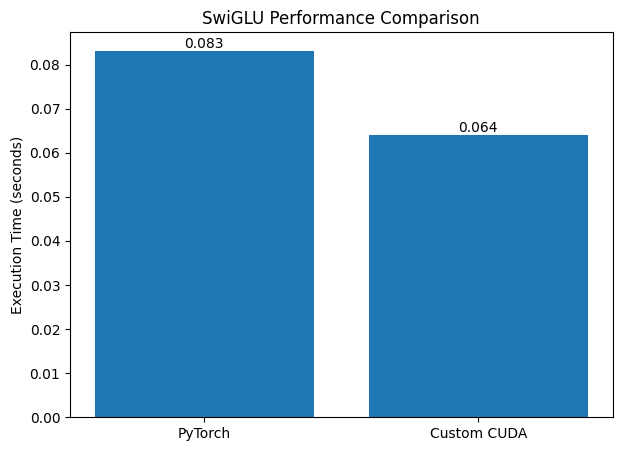

In [25]:
# Performance Plot

plt.figure(figsize=(7,5))

times = [pytorch_time, cuda_time]

labels = ["PyTorch", "Custom CUDA"]

bars = plt.bar(labels, times)

plt.ylabel("Execution Time (seconds)")

plt.title("SwiGLU Performance Comparison")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.show()